# M1: Decision tree

## Using sklearn python library


`criterion='gini', max_depth=9, min_samples_split=100, min_samples_leaf=10`

Accuracy: 80.02%


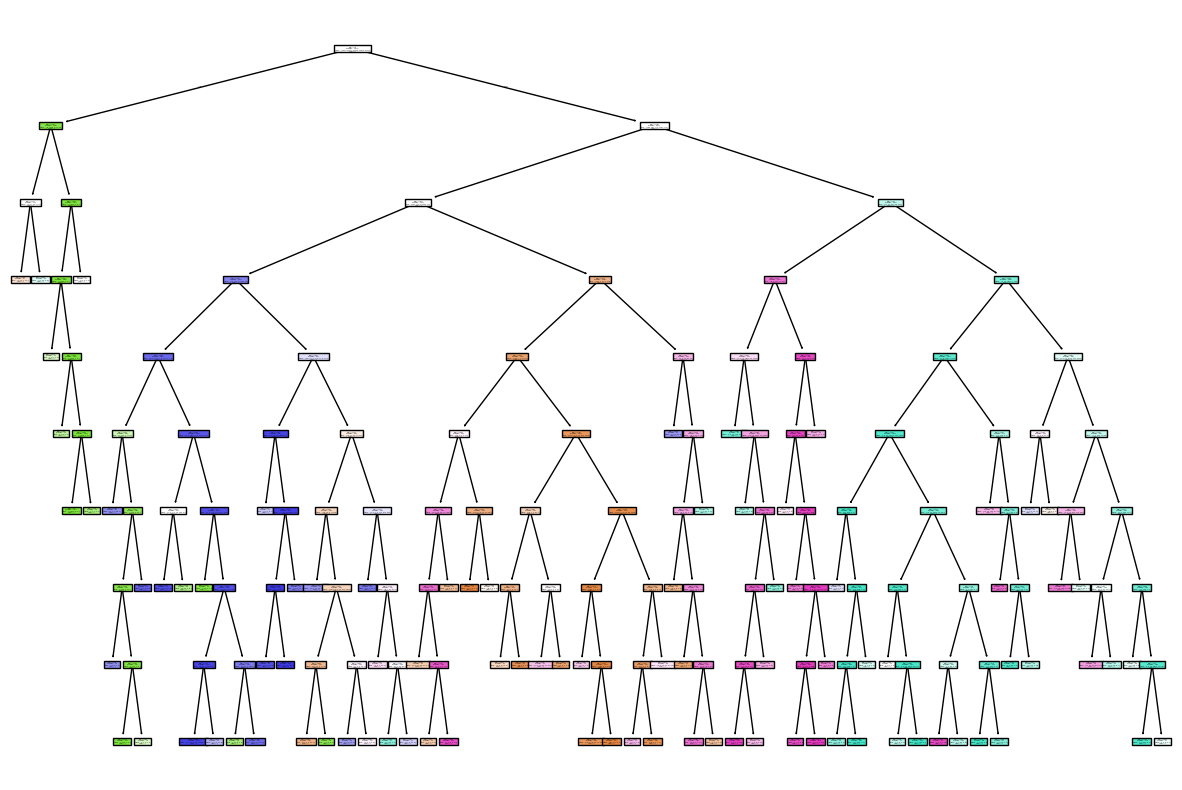

In [20]:
from sklearn.tree import DecisionTreeClassifier 
import numpy as np 
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Step 1: Load the Dataset
train_data = np.load('fashion_train.npy')  # Replace with actual file path
test_data = np.load('fashion_test.npy')    # Replace with actual file path

X_train = train_data[:, :-1]  # Features for training
y_train = train_data[:, -1]   # Labels for training

X_test = test_data[:, :-1]    # Features for testing
y_test = test_data[:, -1]     # Labels for testing

# Step 2: Initialize and Train the Decision Tree
clf = DecisionTreeClassifier(criterion='gini', max_depth=9, min_samples_split=100, min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

# Step 3: Predict on Test Data
y_pred = clf.predict(X_test)

# Step 4: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Optional: Visualize the Tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
plot_tree(clf, feature_names=[f'Feature {i}' for i in range(X_train.shape[1])], class_names=np.unique(y_train).astype(str), filled=True)
plt.savefig('matus_imgs/dt.png', bbox_inches='tight')  # Save as a PNG file
plt.show()

`Gini vs Entropy`

In [21]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Step 1: Load the Dataset
train_data = np.load('fashion_train.npy')  # Replace with actual file path
test_data = np.load('fashion_test.npy')    # Replace with actual file path

X_train = train_data[:, :-1]  # Features for training
y_train = train_data[:, -1]   # Labels for training

X_test = test_data[:, :-1]    # Features for testing
y_test = test_data[:, -1]     # Labels for testing
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train Decision Tree with Gini
clf_gini = DecisionTreeClassifier(
    criterion='gini', 
    max_depth=9, 
    min_samples_split=100, 
    min_samples_leaf=10, 
    random_state=42
)
clf_gini.fit(X_train, y_train)
y_pred_gini = clf_gini.predict(X_test)
accuracy_gini = accuracy_score(y_test, y_pred_gini)

# Train Decision Tree with Entropy
clf_entropy = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=9, 
    min_samples_split=100, 
    min_samples_leaf=10, 
    random_state=42
)
clf_entropy.fit(X_train, y_train)
y_pred_entropy = clf_entropy.predict(X_test)
accuracy_entropy = accuracy_score(y_test, y_pred_entropy)

# Print the results
print(f"Gini Accuracy: {accuracy_gini:.4f}")
print(f"Entropy Accuracy: {accuracy_entropy:.4f}")

Gini Accuracy: 0.8002
Entropy Accuracy: 0.7802


`Max_depth training/test data vs Accuracy`

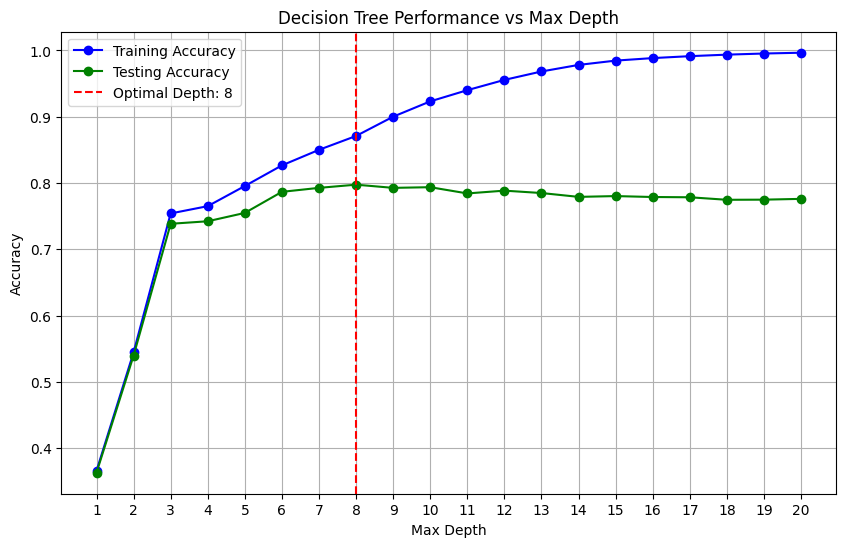

Optimal Max Depth: 8
Best Test Accuracy: 79.74%


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load the Dataset
train_data = np.load('fashion_train.npy')  # Replace with actual file path
test_data = np.load('fashion_test.npy')    # Replace with actual file path

X_train = train_data[:, :-1]  # Features for training
y_train = train_data[:, -1]   # Labels for training

X_test = test_data[:, :-1]    # Features for testing
y_test = test_data[:, -1]     # Labels for testing

# Evaluate Decision Tree with Different Max Depths
max_depths = range(1, 21)  # Test max_depth values from 1 to 20
train_accuracies = []
test_accuracies = []

for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)  # Train the model
    
    # Evaluate on training data
    y_train_pred = clf.predict(X_train)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_accuracy)
    
    # Evaluate on test data
    y_test_pred = clf.predict(X_test)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_accuracies.append(test_accuracy)

# Find the best depth based on test accuracy
optimal_depth = max_depths[np.argmax(test_accuracies)]
best_accuracy = max(test_accuracies)

# Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(max_depths, test_accuracies, label='Testing Accuracy', marker='o', color='green')
plt.axvline(optimal_depth, color='red', linestyle='--', label=f'Optimal Depth: {optimal_depth}')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance vs Max Depth')
plt.legend()
plt.grid(True)

# Ensure X-axis only shows integers
plt.xticks(ticks=max_depths)  # Set X-axis ticks to the range of max_depths

plt.savefig('matus_imgs/decision_tree_max_depth_plot.png', bbox_inches='tight')  # Save as a PNG file
# Show the plot
plt.show()

# Print the best depth and accuracy
print(f"Optimal Max Depth: {optimal_depth}")
print(f"Best Test Accuracy: {best_accuracy * 100:.2f}%")

`Max depth vs Accuracy using 5-fold crossvalidation`

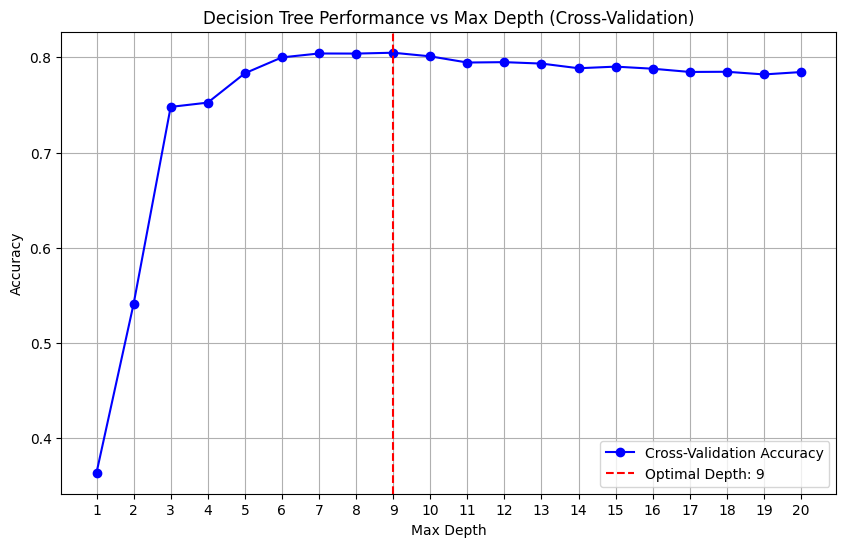

Optimal Max Depth: 9
Best Cross-Validation Accuracy: 80.49%


In [23]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

# Load the Dataset
train_data = np.load('fashion_train.npy')  # Replace with actual file path

X_train = train_data[:, :-1]  # Features for training
y_train = train_data[:, -1]   # Labels for training

# Evaluate Decision Tree with Cross-Validation
max_depths = range(1, 21)  # Test max_depth values from 1 to 20
cv_scores = []

for depth in max_depths:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # Perform 5-fold cross-validation
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    cv_scores.append(np.mean(scores))  # Average accuracy across folds

# Find the optimal depth
optimal_depth = max_depths[np.argmax(cv_scores)]
best_cv_accuracy = max(cv_scores)

# Plot the Results
plt.figure(figsize=(10, 6))
plt.plot(max_depths, cv_scores, label='Cross-Validation Accuracy', marker='o', color='blue')
plt.axvline(optimal_depth, color='red', linestyle='--', label=f'Optimal Depth: {optimal_depth}')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Performance vs Max Depth (Cross-Validation)')
plt.legend()
plt.grid(True)
plt.xticks(ticks=max_depths)  # Set X-axis ticks to the range of max_depths
plt.savefig('matus_imgs/crossvalidation.png', bbox_inches='tight')  # Save as a PNG file
# Show the plot
plt.show()

# Print the optimal depth and accuracy
print(f"Optimal Max Depth: {optimal_depth}")
print(f"Best Cross-Validation Accuracy: {best_cv_accuracy * 100:.2f}%")

`Min samples split / Min samples leaf / Max depth + best accuracy`

FileNotFoundError: [Errno 2] No such file or directory: '/Users/matusstanko/Desktop/ml_a24_project/heatmap_plots/matus_imgs/heatmap_max_depth_5.png'

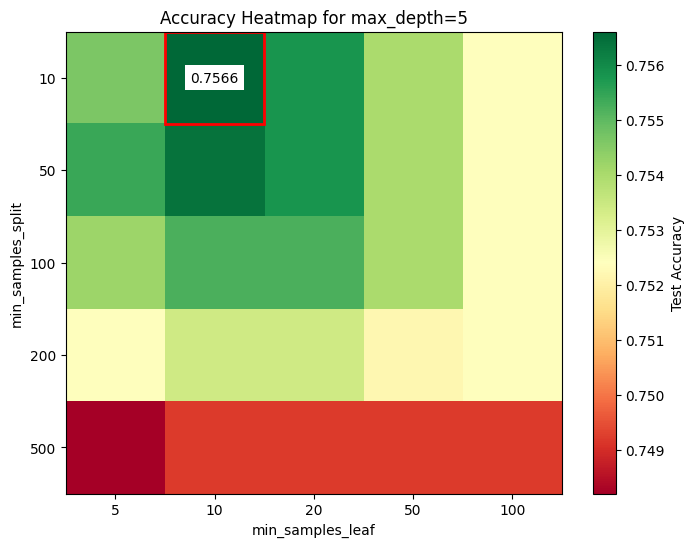

In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Replace with your actual data loading
train_data = np.load('fashion_train.npy')  # Replace with actual file path
test_data = np.load('fashion_test.npy')    # Replace with actual file path

X_train = train_data[:, :-1]  # Features for training
y_train = train_data[:, -1]   # Labels for training

X_test = test_data[:, :-1]    # Features for testing
y_test = test_data[:, -1]     # Labels for testing

# Parameters to test
max_depths = [5, 9, 15, 20, 35, 50]                # Depths to test
min_samples_splits = [10, 50, 100, 200, 500]       # Larger range for high-dimensional data
min_samples_leaves = [5, 10, 20, 50, 100]          # Larger range for smoothing

# Store results
results = []

# Grid search over all three hyperparameters
for depth in max_depths:
    for min_split in min_samples_splits:
        for min_leaf in min_samples_leaves:
            clf = DecisionTreeClassifier(
                max_depth=depth,
                min_samples_split=min_split,
                min_samples_leaf=min_leaf,
                random_state=42
            )
            clf.fit(X_train, y_train)  # Train the model
            
            # Evaluate on test data
            y_test_pred = clf.predict(X_test)
            test_accuracy = accuracy_score(y_test, y_test_pred)
            
            # Save the results
            results.append((depth, min_split, min_leaf, test_accuracy))

# Prepare results for visualization
accuracies = np.array([result[3] for result in results]).reshape(
    len(max_depths), len(min_samples_splits), len(min_samples_leaves)
)

# Directory to save the plots
output_dir = "matus_imgs"
os.makedirs(output_dir, exist_ok=True)  # Create directory if it doesn't exist

# Generate a heatmap for each max_depth and save as an image
for depth_index, depth in enumerate(max_depths):
    selected_accuracies = accuracies[depth_index]

    plt.figure(figsize=(8, 6))
    plt.imshow(selected_accuracies, interpolation='nearest', cmap='RdYlGn', aspect='auto')  # Red-to-Green palette
    plt.colorbar(label='Test Accuracy')
    plt.xticks(range(len(min_samples_leaves)), labels=min_samples_leaves)
    plt.yticks(range(len(min_samples_splits)), labels=min_samples_splits)
    plt.xlabel('min_samples_leaf')
    plt.ylabel('min_samples_split')
    plt.title(f'Accuracy Heatmap for max_depth={depth}')

    # Highlight the best value for this depth
    best_local_index = np.unravel_index(selected_accuracies.argmax(), selected_accuracies.shape)
    best_x, best_y = best_local_index[1], best_local_index[0]
    plt.gca().add_patch(plt.Rectangle((best_x - 0.5, best_y - 0.5), 1, 1, edgecolor='red', fill=False, lw=2))
    
    # Annotate the best accuracy on the plot
    best_value = selected_accuracies[best_y, best_x]
    plt.text(best_x, best_y, f"{best_value:.4f}", color="black", ha="center", va="center", fontsize=10, bbox=dict(facecolor='white', edgecolor='none'))

    # Save the plot as an image
    output_path = os.path.join(output_dir, f"heatmap_max_depth_{depth}.png")
    plt.savefig(output_path, bbox_inches="tight")
    plt.close()

print(f"Plots saved in directory: {output_dir}")

`Accuracy with normalization`

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import MinMaxScaler

# Step 1: Load the Dataset
train_data = np.load('fashion_train.npy')  # Replace with actual file path
test_data = np.load('fashion_test.npy')    # Replace with actual file path

X_train = train_data[:, :-1]  # Features for training
y_train = train_data[:, -1]   # Labels for training

X_test = test_data[:, :-1]    # Features for testing
y_test = test_data[:, -1]     # Labels for testing

# Step 2: Normalize the Features to 0-1 Range
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

# Step 3: Initialize and Train the Decision Tree
clf = DecisionTreeClassifier(max_depth=9, min_samples_split=100, min_samples_leaf=10, random_state=42)
clf.fit(X_train_normalized, y_train)

# Step 4: Predict on Test Data
y_pred = clf.predict(X_test_normalized)

# Step 5: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy (with normalization): {accuracy * 100:.2f}%")

Accuracy (with normalization): 80.04%


-------------

## Using implementation from scratch


`Import numpy`

In [ ]:
import numpy as np

`Gini Impurity`

In [ ]:
def gini_impurity(y):
    # Total number of data points
    num_samples = len(y)

    # Count occurrences of each class
    class_counts = np.unique(y, return_counts=True)[1]
    
    # Calculate probabilities for each class
    probabilities = class_counts / num_samples
    
    # Compute Gini Impurity: 1 - sum of squared probabilities
    gini = 1 - np.sum(probabilities ** 2)
    
    return gini

`Find best split`

In [ ]:
def find_best_split(X, y):
    # Initialize the best Gini Impurity to a very large value
    best_gini = float('inf')  
    # Placeholder for the best split (feature and threshold)
    best_split = None  
    
    # Number of features in the dataset
    n_features = X.shape[1]  

    # Loop through each feature (column)
    for feature in range(n_features):
        # Get unique values of the feature as potential split points
        thresholds = np.unique(X[:, feature])

        # Test each threshold
        for threshold in thresholds:
            # Split data into two groups: left (<= threshold) and right (> threshold)
            left_indices = X[:, feature] <= threshold
            right_indices = X[:, feature] > threshold

            # Skip this threshold if it doesn't split the data
            if np.sum(left_indices) == 0 or np.sum(right_indices) == 0:
                continue

            # Calculate Gini Impurity for the left and right groups
            g_left = gini_impurity(y[left_indices])
            g_right = gini_impurity(y[right_indices])

            # Calculate the weighted average of Gini Impurities
            g_split = ((np.sum(left_indices) / len(y)) * g_left +
                       (np.sum(right_indices) / len(y)) * g_right)

            # Update the best split if this one is better (lower Gini Impurity)
            if g_split < best_gini:
                best_gini = g_split
                best_split = {'feature': feature, 'threshold': threshold}

    # Return the best split (feature and threshold)
    return best_split

`Build Decision tree`

In [ ]:
# Step 3: Build the Decision Tree
# This function builds the decision tree recursively
def build_tree(X, y, max_depth, depth=0):
    # Stopping condition: if all labels are the same, return the label
    if len(np.unique(y)) == 1:
        return {'class': y[0]}

    # Stopping condition: if max depth is reached or no data left to split
    if depth == max_depth or len(y) <= 1:
        # Return the majority class in this subset
        return {'class': np.argmax(np.bincount(y.astype(int)))}

    # Find the best split
    split = find_best_split(X, y)
    if not split:
        return {'class': np.argmax(np.bincount(y.astype(int)))}

    # Split the data into left and right subsets
    feature, threshold = split['feature'], split['threshold']
    left_indices = X[:, feature] <= threshold
    right_indices = X[:, feature] > threshold

    # Recursively build left and right branches of the tree
    return {
        'feature': feature,
        'threshold': threshold,
        'left': build_tree(X[left_indices], y[left_indices], depth + 1, max_depth),
        'right': build_tree(X[right_indices], y[right_indices], depth + 1, max_depth)
    }

`Predict class for each data point`

In [ ]:
def predict(tree, X):
    # Helper function to predict the class for a single data point
    def predict_one(tree, x):
        # If the current node is a leaf, return the stored class
        if 'class' in tree:
            return tree['class']

        # Otherwise, check the feature and threshold to decide the next branch
        if x[tree['feature']] <= tree['threshold']:
            # Go to the left child if the condition is true
            return predict_one(tree['left'], x)
        else:
            # Otherwise, go to the right child
            return predict_one(tree['right'], x)

    # Apply the helper function to each row in the input data
    return np.array([predict_one(tree, x) for x in X])

`Load the data and separate features and classes`

In [ ]:
# Step 5: Load Dataset
# Example dataset (replace with fashion_train.npy and fashion_test.npy)
train_data = np.load('fashion_train.npy')  # Load training data
test_data = np.load('fashion_test.npy')    # Load testing data

X_train = train_data[:, :-1]  # Features from training data
y_train = train_data[:, -1]   # Labels from training data

X_test = test_data[:, :-1]    # Features from testing data
y_test = test_data[:, -1]     # Labels from testing data

`Train tree using hyperparameters founded in sklearn library implementation of DT and calculate accuracy`

In [ ]:
tree = build_tree(X_train, y_train, max_depth=9)

predictions = predict(tree, X_test)
accuracy = np.mean(predictions == y_test)  # Calculate accuracy
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 76.80%
